In [1]:
import getdist.plots as gdplt
import numpy as np
import matplotlib.pyplot as plt
from cobaya import load_samples
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
from cosmoprimo import Cosmology
import cosmoprimo
import os
import camb

plt.rcParams['text.usetex'] = False
plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'cm'

plt.rc('xtick', labelsize=12) 
plt.rc('ytick', labelsize=12)
plt.rc('font', size=14)
plt.rc('axes', labelsize=16)

path_to_fig = r'C:\EPFL\MA4\code\PDM2026\figures'

### fct

In [20]:
def get_slope_pivot_z(sample):
    cov_w_wa = sample.cov(['w', 'wa'])
    covar = cov_w_wa[0, 1]
    var_wa = cov_w_wa[1, 1]

    eigvals, eigvecs = np.linalg.eigh(cov_w_wa) # eigh for hermintian or symmetric matrices
    major_axis = eigvecs[:, np.argmax(eigvals)]
    slope = major_axis[1] / major_axis[0]
    slope_alt = 1/ (covar / var_wa)
    
    ap = 1+1/slope
    ap_alt = 1+1/slope_alt
    zp = 1/ap -1
    zp_alt = 1/ap_alt -1
    return slope, slope_alt, zp, zp_alt

def get_FoM(sample):
    cov_w_wa = sample.cov(['w', 'wa'])
    det = np.linalg.det(cov_w_wa)
    FoM = 1 / np.sqrt(det)
    return FoM

def print_FoM_slope_zp(gd_samples, labels):
    for i, label in enumerate(labels):    
        FoM = get_FoM(gd_samples[i])
        _, slope, _, zp = get_slope_pivot_z(gd_samples[i])
        print(f"{label}: FoM = {FoM:.4f}, slope = {slope:.4f}, zp = {zp:.4f}")


In [2]:
def get_DESI_errors():
    dict_distance, z_DESI, path = get_DESI_data()

    cov_mat = np.loadtxt(path.replace('mean', 'cov'))

    errors = {}
    for i in range(len(cov_mat[0, :])):
        z = z_DESI[i//2]
        if i == 0:
            _, _, DVfid = get_DESI_fid(z)
            a_iso_err = np.sqrt(cov_mat[i][i]) / DVfid
            errors[z] = {'d_iso': a_iso_err}
        elif i%2 == 0:
            cov = [[cov_mat[i-1, i-1], cov_mat[i-1, i]], [cov_mat[i, i-1], cov_mat[i, i]]]
            sig_x = np.sqrt(cov[0][0])
            sig_y = np.sqrt(cov[1][1])

            DMfid, DHfid, DVfid = get_DESI_fid(z)
            if i == len(cov_mat[0, :])-1:
                d_a_perp = sig_y / DMfid
                d_a_par = sig_x / DHfid                
            else :
                d_a_perp = sig_x / DMfid
                d_a_par = sig_y / DHfid

            DM = dict_distance[z]['DM_over_rs']
            DH = dict_distance[z]['DH_over_rs']
            DV = (z*DM**2*DH)**(1/3)

            a_perp = DM / DMfid
            a_par = DH / DHfid
            a_iso = DV / DVfid
            a_AP = a_par / a_perp

            d_a_AP = a_AP * np.sqrt((d_a_par / a_par)**2 + (d_a_perp / a_perp)**2)
            d_a_iso = a_iso * np.sqrt((2/3)**3 * (d_a_perp / a_perp)**2 + (1/3)**2 * (d_a_par / a_par)**2)

            errors[z] = {'d_perp':  d_a_perp,
                         'd_par':   d_a_par,
                         'd_AP':    d_a_AP,
                         'd_iso':   d_a_iso
                         }
    return errors, z_DESI

def get_DESI_data():
    z_DESI = []
    path = r'C:\EPFL\MA4\code\COBAYA_packages\data\bao_data\desi_bao_dr2\desi_gaussian_bao_ALL_GCcomb_mean.txt'
    with open(path, 'r') as f:
        for line in f:
            if line.startswith('#'):
                continue
            parts = line.split()
            z_DESI.append(float(parts[0]))

    z_DESI = set(z_DESI)
    z_DESI = list(z_DESI)
    z_DESI.sort()
    dict_distance = {}
    for z in z_DESI:
        dict_distance[z] = {}

    with open(path, 'r') as f:
        for line in f:
            if line.startswith('#'):
                continue
            parts = line.split()
            z = float(parts[0])
            for key in dict_distance.keys():
                if key == z:
                    dict_distance[key][parts[2]] = float(parts[1])
    
    return dict_distance, z_DESI, path

def get_DESI_fid(redshift):
    DESI = cosmoprimo.fiducial.DESI(engine='camb')
    DESI_bkg = DESI.get_background()
    DESI_thermo = DESI.get_thermodynamics()
    rdrag_fid = DESI_thermo.rs_drag
    DM_fid = DESI_bkg.comoving_angular_distance(redshift)
    DH_fid = 1 / DESI_bkg.efunc(redshift) * 2997.92458 # c/H(z) in Mpc, c=299792 km/s, H0 in km/s/Mpc
    DV_fid = (redshift * DM_fid**2 * DH_fid)**(1/3)
    DMover_rd_fid = DM_fid / rdrag_fid
    DHover_rd_fid = DH_fid / rdrag_fid
    DVover_rd_fid = DV_fid / rdrag_fid

    return DMover_rd_fid, DHover_rd_fid, DVover_rd_fid

### degeneracy lines 

In [62]:
gd_sample_DR2 = load_samples(r'C:\EPFL\MA4\code\old_stuff.bak\cobaya_runs\DESI_data\base_w_wa\run1', to_getdist=True, skip=0.33) # DESI all z run using w0waCDM

var_names = ['w', 'wa']

In [63]:
path_to_chains = r'C:\EPFL\MA4\code\old_stuff.bak\DESI_DR2_chains'
pathCMB_LCDM = path_to_chains + r'\base\desi-bao-all_planck2018-lowl-TT-clik_planck2018-lowl-EE-clik_planck-NPIPE-highl-CamSpec-TTTEEE\chain'
pathCMB = path_to_chains + r'\base_w_wa\desi-bao-all_planck2018-lowl-TT-clik_planck2018-lowl-EE-clik_planck-NPIPE-highl-CamSpec-TTTEEE\chain'
# path3 = r'..\..\DESI_DR2_chains\base\desy5sn\chain'
pathUnion = path_to_chains + r'\base_w_wa\desi-bao-all_union3_planck2018-lowl-TT-clik_planck2018-lowl-EE-clik_planck-NPIPE-highl-CamSpec-TTTEEE_planck-act-dr6-lensing\chain'
pathPantheon = path_to_chains + r'\base_w_wa\desi-bao-all_pantheonplus_planck2018-lowl-TT-clik_planck2018-lowl-EE-clik_planck-NPIPE-highl-CamSpec-TTTEEE_planck-act-dr6-lensing\chain'
pathDESY5 = path_to_chains + r'\base_w_wa\desi-bao-all_desy5sn_planck2018-lowl-TT-clik_planck2018-lowl-EE-clik_planck-NPIPE-highl-CamSpec-TTTEEE_planck-act-dr6-lensing\chain'

gd_sampleCMB = load_samples(pathCMB, to_getdist=True, skip=0.33)
# gd_sample3 = load_samples(path3, to_getdist=True, skip=0.33)
gd_sampleUnion = load_samples(pathUnion, to_getdist=True, skip=0.33)
gd_samplePantheon = load_samples(pathPantheon, to_getdist=True, skip=0.33)
gd_sampleDESY5 = load_samples(pathDESY5, to_getdist=True, skip=0.33)

In [64]:
gd_sample_all = [gd_sample_DR2, gd_sampleCMB, gd_sampleDESY5]

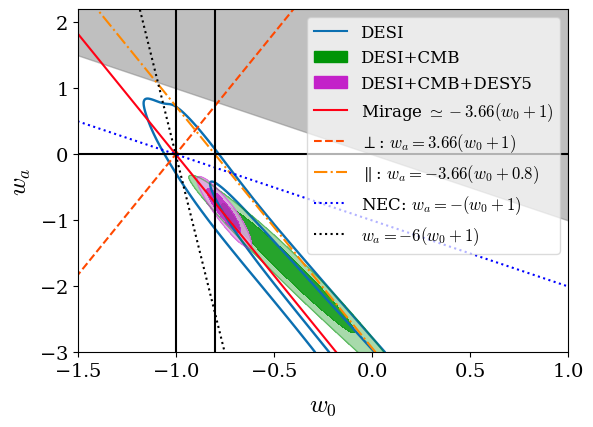

In [ ]:
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

gdplot = gdplt.get_single_plotter()
gdplot.settings.axes_labelsize = 18
gdplot.settings.axes_fontsize = 14

contour_colors = ["#0B6FB1", '#009407', '#c320c9']
gdplot.settings.solid_colors = contour_colors

gdplot.plot_2d(gd_sample_all, 'w', 'wa',
    filled=[False, True, True],
    line_args=[
        {'color': contour_colors[0], 'ls': '-'},
        {'color': contour_colors[1]},
        {'color': contour_colors[2]}
    ]
)

ax = gdplot.get_axes()

x_fit = np.linspace(-2, 1, 100)

c_mirage = "#FF0015"
c_perp   = "#FF4800"
c_para   = "#FF8800"
c_nec    = 'b'
c_steep  = 'k'

ax.plot(x_fit, -3.66 * (x_fit + 1),    color=c_mirage, ls='-')
ax.plot(x_fit,  3.66 * (x_fit + 1),    color=c_perp,   ls='--')
ax.plot(x_fit, -3.66 * (x_fit + 0.8),  color=c_para,   ls='-.')
ax.plot(x_fit, -1.0  * (x_fit + 1.0),  color=c_nec,    ls=':')
ax.plot(x_fit, -12    * (x_fit + 1.0),  color=c_steep,  ls=':')

ax.fill_between(x_fit, -x_fit, 3, color='gray', alpha=0.5)
ax.axhline(0,  color='k', ls='-')
ax.axvline(-1, color='k', ls='-')

ax.axvline(-0.8, color='k', ls='-')

legend_handles = [
    mlines.Line2D([], [], color=contour_colors[0], ls='-',
                  label='DESI'),
    mpatches.Patch(color=contour_colors[1], label='DESI+CMB'),
    mpatches.Patch(color=contour_colors[2], label='DESI+CMB+DESY5'),
    mlines.Line2D([], [], color=c_mirage, ls='-',
                  label=r'Mirage $\simeq -3.66(w_0+1)$'),
    mlines.Line2D([], [], color=c_perp,   ls='--',
                  label=r'$\perp$: $w_a = 3.66(w_0+1)$'),
    mlines.Line2D([], [], color=c_para,   ls='-.',
                  label=r'$\parallel$: $w_a = -3.66(w_0+0.8)$'),
    mlines.Line2D([], [], color=c_nec,    ls=':',
                  label=r'NEC: $w_a = -(w_0+1)$'),
    mlines.Line2D([], [], color=c_steep,  ls=':',
                  label=r'$w_a = -12(w_0+1)$')#,
]

ax.legend(handles=legend_handles, fontsize=12, framealpha=0.7)

ax.set_xlim(-1.5, 1.0)
ax.set_ylim(-3, 2.2)

fig = gdplot.fig
# fig.savefig(r'..\..\figures\degen_line\w_wa_contour_cmb_desy5.png', dpi=300)

### $w_0 w_a$ pair

In [3]:
def get_slope_pivot_z(sample):
    cov_w_wa = sample.cov(['w', 'wa'])
    covar = cov_w_wa[0, 1]
    var_wa = cov_w_wa[1, 1]

    eigvals, eigvecs = np.linalg.eigh(cov_w_wa) # eigh for hermintian or symmetric matrices
    major_axis = eigvecs[:, np.argmax(eigvals)]
    slope = major_axis[1] / major_axis[0]
    slope_alt = 1/ (covar / var_wa)
    
    ap = 1+1/slope
    ap_alt = 1+1/slope_alt
    zp = 1/ap -1
    zp_alt = 1/ap_alt -1
    return slope, slope_alt, zp, zp_alt

def get_Om_hrdrag(w0, wa):
    '''
    For each (w0, wa) pair, uses CAMB to get Omega_m, h*rdrag, h
    by fixing theta_star=0.01041, omega_b=0.02223, omega_bc=0.14208
    Dark energy initialized first, H0 set to None.
    
    Accepts scalars or lists/arrays for w0, wa.
    Returns Omega_m, hrdrag, h (arrays if input is array)
    '''

    scalar_input = np.ndim(w0) == 0
    w0 = np.atleast_1d(w0)
    wa = np.atleast_1d(wa)

    Omega_m_list = []
    hrdrag_list = []
    h_list = []

    for w0_i, wa_i in zip(w0, wa):
        # cosmo.
        pars = camb.CAMBparams()
        
        # Initialize dark energy first
        pars.set_dark_energy(w=w0_i, wa=wa_i, dark_energy_model='ppf')
        
        pars.set_cosmology(
            thetastar=0.01041,
            ombh2=0.02223,
            # omch2=0.14208-0.02223,
            omch2=0.141434-0.02223,
            H0=None
        )

        results = camb.get_background(pars)
        
        h = pars.h
        Omega_m = pars.omegam
        rdrag = results.get_derived_params()['rdrag']
        hrdrag = h * rdrag

        Omega_m_list.append(Omega_m)
        hrdrag_list.append(hrdrag)
        h_list.append(h)

    Omega_m_arr = np.array(Omega_m_list)
    hrdrag_arr = np.array(hrdrag_list)
    h_arr = np.array(h_list)

    if scalar_input:
        return Omega_m_arr[0], hrdrag_arr[0], h_arr[0]
    
    return Omega_m_arr, hrdrag_arr, h_arr

def get_bao_observables(zbins, w0=-1.0, wa=0.0, h=0.6736, Omega_cdm=0.2640, Omega_b=0.0493, n_s=0.9649, A_s=2.083e-9, DESI_fiducial=True, Om=None, hrdrag=None):
    
    c_km_s = 299792.458  # km/s

    if DESI_fiducial:
        fid_params = {
            k: (v.tolist() if hasattr(v, 'tolist') else v)
            for k, v in cosmoprimo.fiducial.DESI(engine='camb')._params.items()
        }   # we use the fiducial DESI cosmology as a base, and then we change w0 and wa
    else :
        fid_params = {
            'h': h,
            'Omega_cdm': Omega_cdm,
            'Omega_b': Omega_b,
            'n_s': n_s,
            'A_s': A_s,
            'w0_fld': w0,
            'wa_fld': wa,
            # 'Omega_Lambda': 0.0
        }
        
    fid_params['w0_fld'] = w0   
    fid_params['wa_fld'] = wa

    if (Om is not None) and (hrdrag is not None):
        cosmo = cosmoprimo.Cosmology(w0_fld=w0, wa_fld=wa, Omega_m=Om, engine='camb')
        DM_rd = np.array([cosmo.comoving_transverse_distance(z) for z in zbins]) / hrdrag
        DH_rd = np.array([c_km_s / (cosmo.hubble_function(z)/h) for z in zbins]) / hrdrag
        DV_rd = (zbins * (DM_rd * hrdrag)**2 * (DH_rd * hrdrag))**(1/3) / hrdrag
    else:

        cosmo = cosmoprimo.Cosmology(**fid_params, engine='camb')
        
        rd = cosmo.rs_drag
        h = fid_params['h']
        zbins = np.atleast_1d(zbins)
        
        DM_rd = np.array([cosmo.comoving_angular_distance(z) for z in zbins]) / rd
        DH_rd = np.array([c_km_s / (cosmo.hubble_function(z)/h) for z in zbins]) / rd
        DV_rd = (zbins * (DM_rd * rd)**2 * (DH_rd * rd))**(1/3) / rd

    return DM_rd, DH_rd, DV_rd

def create_data_file(redshifts, w0=-1.0, wa=0.0, DESI_style=False, Om=None, hrdrag=None):

    DM_rd, DH_rd, DV_rd = get_bao_observables(redshifts, w0=w0, wa=wa, Om=Om, hrdrag=hrdrag)

    data_typ = ['DH_over_rs', 'DM_over_rs', 'DV_over_rs']

    fake_data = []
    if isinstance(DESI_style, list):
        for i in range(len(redshifts)):
            if DESI_style[i]:
                line = [f"{float(redshifts[i]):.8e}", f"{DV_rd[i]:.8e}", data_typ[2]]
                fake_data.append(line)
            else:
                line = [f"{redshifts[i]:.8e}", f"{DM_rd[i]:.8e}", data_typ[1]]
                fake_data.append(line)
                line = [f"{redshifts[i]:.8e}", f"{DH_rd[i]:.8e}", data_typ[0]]
                fake_data.append(line)
    elif isinstance(DESI_style, bool) and DESI_style:
        for i in range(1, len(redshifts)):
            line = [f"{redshifts[i]:.8e}", f"{DM_rd[i]:.8e}", data_typ[1]]
            fake_data.append(line)
            line = [f"{redshifts[i]:.8e}", f"{DH_rd[i]:.8e}", data_typ[0]]
            fake_data.append(line)

        line = [f"{float(redshifts[0]):.8e}", f"{DV_rd[0]:.8e}", data_typ[2]]
        fake_data.insert(0, line)
    else:
        for i in range(len(redshifts)):
            line = [f"{redshifts[i]:.8e}", f"{DM_rd[i]:.8e}", data_typ[1]]
            fake_data.append(line)
            line = [f"{redshifts[i]:.8e}", f"{DH_rd[i]:.8e}", data_typ[0]]
            fake_data.append(line)

    return np.array(fake_data)

def save_mean_data(fake_data, folder, filename, overwrite=False):
    if not os.path.exists(folder):
        os.makedirs(folder)
    f = folder + r'\\' 
    f += filename
    if os.path.exists(f):
        if overwrite:
            print("Overwriting file:", f)
            np.savetxt(f, fake_data, fmt="%s")
        else:
            print("File already exists:", f)
    else:
        np.savetxt(f, fake_data, fmt="%s")

In [4]:
# fid_params = {
#     k: (v.tolist() if hasattr(v, 'tolist') else v)
#     for k, v in cosmoprimo.fiducial.DESI(engine='camb')._params.items()
# }   # we use the fiducial DESI cosmology as a base, and then we change w0 and wa

    
# fid_params['w0_fld'] = -1 
# fid_params['wa_fld'] = 0

# cosmo = cosmoprimo.Cosmology(**fid_params, engine='camb')

# rd = cosmo.rs_drag

In [5]:
# print(rd, cosmo._params)

In [6]:
_, z_DESI, _ = get_DESI_data()

# DM_rd, DH_rd, DV_rd = get_bao_observables(zbins=z_DESI, w0=-0.4, wa=-0.6)

In [7]:
w0 = -0.8
# wa = -1.0*(1+w0)  # NEC line
# wa = -3.66*(1+w0)  # NEC line
wa = -12*(1+w0)  # steep line
# wa=0
print(wa)

-2.3999999999999995


In [8]:
folder = r'C:\EPFL\MA4\code\PDM2026\wwa_pair_data'
filename = f'steep_w0_{w0:.1f}_wa_{wa:.1f}.txt'
save_mean_data(create_data_file(z_DESI, w0=w0, wa=wa, DESI_style=True), folder, filename, overwrite=False)

File already exists: C:\EPFL\MA4\code\PDM2026\wwa_pair_data\\steep_w0_-0.8_wa_-2.4.txt


In [9]:
folder_fixed = r'C:\EPFL\MA4\code\PDM2026\wwa_pair_data\fixed'
folder_free = r'C:\EPFL\MA4\code\PDM2026\wwa_pair_data\free'

_, z_DESI, _ = get_DESI_data()

w0 = [-0.4, -1.3, -0.8]
wa = [-1*(1+w0[0]), -3.66*(1+w0[1]), -12*(1+w0[2])]
Om_fixed, hrd_fixed = 0.315, 99
Om_free, hrd_free, _ = get_Om_hrdrag(w0, wa)

line_labels = ['NEC', 'Mirage', 'Steep']

for i in range(len(w0)):
    filename_fixed = f'{line_labels[i]}_fixed_w0_{w0[i]:.1f}_wa_{wa[i]:.1f}.txt'
    filename_free = f'{line_labels[i]}_free_w0_{w0[i]:.1f}_wa_{wa[i]:.1f}.txt'

    save_mean_data(create_data_file(z_DESI, w0=w0[i], wa=wa[i], Om=Om_fixed, hrdrag=hrd_fixed, DESI_style=True), folder_fixed, filename_fixed, overwrite=False)
    save_mean_data(create_data_file(z_DESI, w0=w0[i], wa=wa[i], Om=Om_free[i], hrdrag=hrd_free[i], DESI_style=True), folder_free, filename_free, overwrite=False)

File already exists: C:\EPFL\MA4\code\PDM2026\wwa_pair_data\fixed\\NEC_fixed_w0_-0.4_wa_-0.6.txt
File already exists: C:\EPFL\MA4\code\PDM2026\wwa_pair_data\free\\NEC_free_w0_-0.4_wa_-0.6.txt
File already exists: C:\EPFL\MA4\code\PDM2026\wwa_pair_data\fixed\\Mirage_fixed_w0_-1.3_wa_1.1.txt
File already exists: C:\EPFL\MA4\code\PDM2026\wwa_pair_data\free\\Mirage_free_w0_-1.3_wa_1.1.txt
File already exists: C:\EPFL\MA4\code\PDM2026\wwa_pair_data\fixed\\Steep_fixed_w0_-0.8_wa_-2.4.txt
File already exists: C:\EPFL\MA4\code\PDM2026\wwa_pair_data\free\\Steep_free_w0_-0.8_wa_-2.4.txt


### on the NEC line

#### old code

In [ ]:
labels = ['DESI DR2', 'NEC line run1', 'NEC line run2']

path_DESI_DR2 = r'C:\EPFL\MA4\code\old_stuff.bak\cobaya_runs\fake_data\Planck_flat_LCDM\exact\all_z\chain'
path_nec_run1 = r'C:\EPFL\MA4\code\PDM2026\wwa_pair_chains\NEC_w0_0_wa_neg1\run1.bak\chain'
path_nec_run2 = r'C:\EPFL\MA4\code\PDM2026\wwa_pair_chains\NEC_w0_0_wa_neg1\chain'

gd_sample = [load_samples(path_DESI_DR2, to_getdist=True, skip=0.3),
            load_samples(path_nec_run1, to_getdist=True, skip=0),
            load_samples(path_nec_run2, to_getdist=True, skip=0)
            ]

mask = [1, 1, 1]

contour_colors = [
    "#000000",  # DESI DR2
    "#B7D95F",  # 
    "#AF0505",  # 
    # "#FF6347"   #  
]

filling = [False, True, True]
alphas = [1, 1, 1]
filling = np.array(filling)
alphas = np.array(alphas)

lw = 1.0
line_args = [{'color': contour_colors[0], 'lw': lw},
             {'color': contour_colors[1], 'lw': lw},
             {'color': contour_colors[2], 'lw': lw},
            #  {'color': contour_colors[3], 'lw': lw}]
            #  {'color': contour_colors[4], 'lw': lw},
            #  {'color': contour_colors[5], 'lw': lw},
            #  {'color': contour_colors[6], 'lw': lw},
            #  {'color': contour_colors[7], 'lw': lw}]
]
line_args = np.array(line_args)

legend_handles = []
for idx, f in enumerate(filling):
    if f:
        legend_handles.append(mpatches.Patch(color=contour_colors[idx], label=labels[idx]))
    else:
        legend_handles.append(mlines.Line2D([], [], color=contour_colors[idx], label=labels[idx], lw=1.5))

# legend_handles = [mpatches.Patch(color=contour_colors[0], label=labels[0]),
#                   mlines.Line2D([], [], color=contour_colors[1], label=labels[1], lw=1.5),
#                   mpatches.Patch(color=contour_colors[2], label=labels[2]),
#                   mpatches.Patch(color=contour_colors[3], label=labels[3]),
#                   mpatches.Patch(color=contour_colors[4], label=labels[4])]
legend_handles = np.array(legend_handles)

# contour_colors = [

#     "#F6B725",  # Golden Yellow
#     "#F16220",  # Orange
#     "#7062D1",  # Purple
#     "#618EBC",  # Steel Blue
#     "#77AD89",  # Sage Green
#     "#882392",  # Dark Purple
#     "#000000",  # Black
#     "#09FFFF"  # cmb
# ]

# labels = ['Euclid', 'DESI DR2', 'fullsky test', 'fullsky DESI-like', 'DESI splitBGS', 'DESI forecast', 'DESI splitBGS']

mask = np.array(mask, dtype=bool)
gd_sample = [g for g, keep in zip(gd_sample, mask) if keep]
contour_colors = [color for color, keep in zip(contour_colors, mask) if keep]
filling = [fill for fill, keep in zip(filling, mask) if keep]
alphas = [alpha for alpha, keep in zip(alphas, mask) if keep]
line_args = [arg for arg, keep in zip(line_args, mask) if keep]
legend_handles = [handle for handle, keep in zip(legend_handles, mask) if keep]

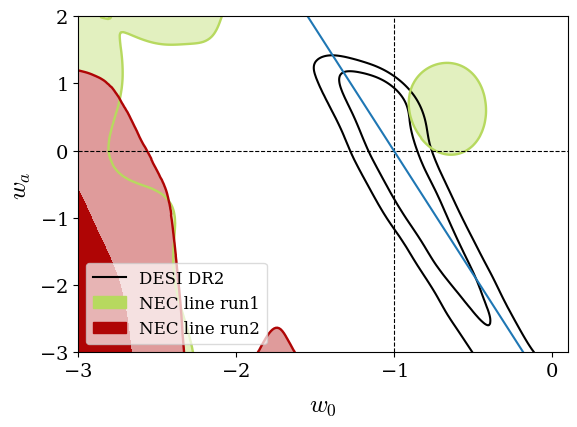

In [24]:
names = ["w", "wa"] 
# names = ["omegam", "hrdrag"] 

gdplot = gdplt.get_single_plotter()
gdplot.settings.axes_labelsize = 18
gdplot.settings.axes_fontsize = 14
gdplot.settings.solid_colors = contour_colors
gdplot.settings.alpha_factor_contour_lines = 1.0


gdplot.plot_2d(gd_sample, names[0], names[1],
    filled=filling,
    alphas=alphas,
    line_args=line_args
)

ax = gdplot.get_axes()

ax.legend(handles=legend_handles, fontsize=12, framealpha=0.7, loc='lower left')

ax.axhline(0,  color='k', ls='--', lw=0.8)
ax.axvline(-1, color='k', ls='--', lw=0.8)

#Mirage line
x_line = np.linspace(-3, 1, 10)
y_line = -3.66 * (x_line + 1)
ax.plot(x_line, y_line, ls='-', lw=1.5, label='Mirage line')


ax.set_xlabel(r'$w_0$', fontsize=18)
ax.set_ylabel(r'$w_a$', fontsize=18)

# ax.set_xlim(-2.5, 0.0)
# ax.set_ylim(-3.0, 2)

fig = gdplot.fig
# fig.savefig(path_to_fig + r'\forecast\DESI_like\DESI_full_split.pdf', dpi=200)
# fig.savefig(path_to_fig + r'\forecast\Euclid.pdf', dpi=300)

In [ ]:
labels = ['DESI DR2', 'NEC line run1', 'NEC line run2']

path_DESI_DR2 = r'C:\EPFL\MA4\code\old_stuff.bak\cobaya_runs\fake_data\Planck_flat_LCDM\exact\all_z\chain'
path_nec_run1 = r'C:\EPFL\MA4\code\PDM2026\wwa_pair_chains\NEC_w0_0_wa_neg1\run1.bak\chain'
path_nec_run2 = r'C:\EPFL\MA4\code\PDM2026\wwa_pair_chains\NEC_w0_0_wa_neg1\chain'

gd_sample = [load_samples(path_DESI_DR2, to_getdist=True, skip=0.3),
            load_samples(path_nec_run1, to_getdist=True, skip=0),
            load_samples(path_nec_run2, to_getdist=True, skip=0)
            ]

contour_colors = [
    "#000000",  # DESI DR2
    "#B7D95F",  # 
    "#AF0505",  # 
    # "#FF6347"   #  
]

filling = [False, True, True]
alphas = [1, 1, 1]

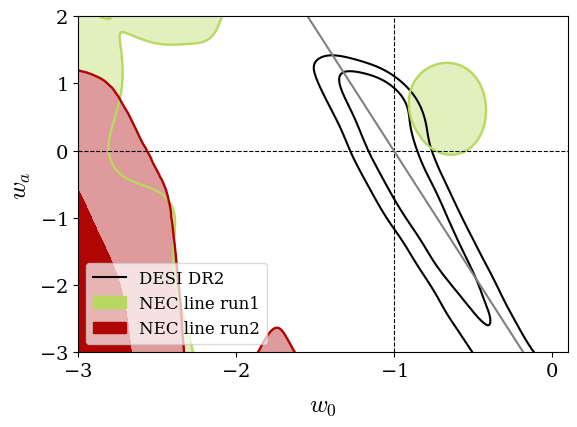

In [ ]:
# fig, ax = plot_w0wa_contours(
#     gd_samples=gd_sample,
#     labels=labels,
#     contour_colors=contour_colors,
#     filling=filling,
#     alphas=alphas,
#     # xlim=(-2.5, 0.0),
#     # ylim=(-3.0, 2.0),
#     # savepath=r'C:\EPFL\MA4\fig\w0wa.pdf'
# )

#### w0wa plot

##### def

In [10]:
def plot_w0wa_contours(
    gd_samples,
    labels,
    contour_colors=None,
    filling=None,
    alphas=None,
    params=('w', 'wa'),
    figsize=None,
    xlim=None,
    ylim=None,
    lw=1.0,
    centers=None,
    savepath=None,
    dpi=200,
):
    """
    Plot 2D contours in the w0-wa plane (or any pair of parameters).

    Parameters
    ----------
    gd_samples : list of GetDist MCSamples
        Already-loaded samples (use load_samples(..., to_getdist=True) outside).
    labels : list of str
    contour_colors : list of str, optional
        Hex color codes. Defaults to a predefined palette.
    filling : list of bool, optional
        Whether to fill each contour. Defaults to True for all.
    alphas : list of float, optional
        Alpha for each contour. Defaults to 1 for all.
    params : tuple of str, optional
        Parameters to plot on (x, y). Defaults to ('w', 'wa').
    xlim : tuple, optional
        (xmin, xmax) for x axis.
    ylim : tuple, optional
        (ymin, ymax) for y axis.
    lw : float, optional
        Line width for unfilled contours. Default 1.0.
    savepath : str, optional
        Full path to save the figure. If None, figure is not saved.
    dpi : int, optional
        DPI for saved figure. Default 200.
    """

    n = len(gd_samples)

    # --- defaults ---
    default_colors = ["#000000", "#B7D95F", "#AF0505", "#F6B725", "#7062D1", "#618EBC", "#77AD89"]
    if contour_colors is None:
        contour_colors = default_colors[:n]
    if filling is None:
        filling = [True] * n
    if alphas is None:
        alphas = [1.0] * n

    # --- line args ---
    line_args = []
    for i, color in enumerate(contour_colors):
        this_lw = 1.5 if not filling[i] else lw
        line_args.append({'color': color, 'lw': this_lw})

    # --- legend handles ---
    legend_handles = []
    for i, (label, fill) in enumerate(zip(labels, filling)):
        if fill:
            legend_handles.append(mpatches.Patch(color=contour_colors[i], label=label))
        else:
            legend_handles.append(mlines.Line2D([], [], color=contour_colors[i], label=label, lw=1.5))

    # --- plot ---
    gdplot = gdplt.get_single_plotter()
    gdplot.settings.axes_labelsize = 18
    gdplot.settings.axes_fontsize = 14
    gdplot.settings.solid_colors = contour_colors
    gdplot.settings.alpha_factor_contour_lines = 1.0

    gdplot.plot_2d(
        gd_samples, params[0], params[1],
        filled=filling,
        alphas=alphas,
        line_args=line_args,
    )

    ax = gdplot.get_axes()

    ax.legend(handles=legend_handles, fontsize=14, framealpha=0.7, loc='lower left')

    ax.axhline(0,  color='k', ls='--', lw=0.8)
    ax.axvline(-1, color='k', ls='--', lw=0.8)
    x_fit = np.linspace(-3, 2, 100)
    ax.fill_between(x_fit, -x_fit, 3, color='gray', alpha=0.5)

    # Mirage line (only shown in w0-wa plane)
    if params == ('w', 'wa'):
        x_line = np.linspace(-3, 1, 100)
        y_line = -3.66 * (x_line + 1)
        ax.plot(x_line, y_line, ls='-', lw=1.5, color='magenta', label='Mirage')
        y_line = -1 * (x_line + 1)
        ax.plot(x_line, y_line, ls='-', lw=1, color='blue', label='NEC')

    # --- centers ---
    if centers is not None:
        for i, center in enumerate(centers):
            if center is None:
                continue
            x0, y0 = center
            # ax.plot(x0, y0, '+', color=contour_colors[i], ms=8, mew=1.5)
            ax.plot(x0, y0, 'x', color='black', ms=8, mew=1.5)

    param_labels = {
        'w':   r'$w_0$',
        'wa':  r'$w_a$',
        'omegam': r'$\Omega_m$',
        'hrdrag': r'$h r_\mathrm{drag}$',
    }
    ax.set_xlabel(param_labels.get(params[0], params[0]), fontsize=18)
    ax.set_ylabel(param_labels.get(params[1], params[1]), fontsize=18)

    if xlim is not None:
        ax.set_xlim(*xlim)
    if ylim is not None:
        ax.set_ylim(*ylim)

    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    x_cross = -ylim[1]  # where wa=-w0 meets wa=ylim[1]
    # centroid of the triangle with vertices:
    # (xlim[1], -xlim[1]), (xlim[1], ylim[1]), (x_cross, ylim[1])
    vx = [xlim[1], xlim[1], x_cross]
    vy = [-xlim[1], ylim[1], ylim[1]]
    cx = np.mean(vx)
    cy = np.mean(vy)
    ax.text(cx, cy, r'$w_0 + w_a > 0$',
            fontsize=13, color='black', ha='center', va='center',
            rotation=0)  # optional: rotate to follow the boundary

    # print(gdplot.settings.fig_width_inch)

    fig = gdplot.fig
    # print(fig.get_size_inches())    
    if figsize is not None:
        fig.set_size_inches(*figsize)
    if savepath is not None:
        fig.savefig(savepath, dpi=dpi, bbox_inches='tight')

    return fig, ax

In [11]:
# with relative constant fontsize 

def plot_w0wa_contours_rel_fs(
    gd_samples,
    labels,
    contour_colors=None,
    filling=None,
    alphas=None,
    params=('w', 'wa'),
    figsize=None,
    xlim=None,
    ylim=None,
    lw=1.0,
    centers=None,
    fontsize=14,        # base fontsize — everything scales from this
    savepath=None,
    dpi=200,
):

    def mask_function(minx, miny, stepx, stepy, mask):
        # define function to tell getdist which 2D points are excluded by the prior
        # Note this should not include min, max parameter range cuts aligned with axes, which are handled as above.

        x = np.arange(mask.shape[1]) * stepx + minx
        y = np.arange(mask.shape[0]) * stepy + miny
        # Create 2D coordinate grids
        X, Y = np.meshgrid(x, y)
        # Zero out the array where prior excluded
        mask[Y > -X] = 0

        
    n = len(gd_samples)

    # --- scale fontsize with figsize ---
    base_figsize = 5.2  # reference size
    if figsize is not None:
        scale = (figsize[0] * figsize[1]) ** 0.5 / base_figsize
    else:
        scale = 1.0

    fs       = fontsize / scale        # base
    fs_label = fontsize / scale * 1.3  # axis labels
    fs_tick  = fontsize / scale        # ticks
    fs_leg   = fontsize / scale        # legend

    # --- defaults ---
    default_colors = ["#000000", "#B7D95F", "#AF0505", "#F6B725", "#7062D1", "#618EBC", "#77AD89"]
    if contour_colors is None:
        contour_colors = default_colors[:n]
    if filling is None:
        filling = [True] * n
    if alphas is None:
        alphas = [1.0] * n

    # --- line args ---
    line_args = []
    for i, color in enumerate(contour_colors):
        this_lw = 1.5 if not filling[i] else lw
        line_args.append({'color': color, 'lw': this_lw})

    # --- legend handles ---
    legend_handles = []
    for i, (label, fill) in enumerate(zip(labels, filling)):
        if fill:
            legend_handles.append(mpatches.Patch(color=contour_colors[i], label=label))
        else:
            legend_handles.append(mlines.Line2D([], [], color=contour_colors[i], label=label, lw=1.5))

    # --- plot ---
    gdplot = gdplt.get_single_plotter()
    gdplot.settings.axes_labelsize = fs_label
    gdplot.settings.axes_fontsize  = fs_tick
    gdplot.settings.solid_colors   = contour_colors
    gdplot.settings.alpha_factor_contour_lines = 1.0

    gdplot.plot_2d(
        gd_samples, params[0], params[1],
        filled=filling,
        alphas=alphas,
        line_args=line_args,
        mask_function=mask_function,
    )

    ax = gdplot.get_axes()

    ax.legend(handles=legend_handles, fontsize=fs_leg, framealpha=0.7, loc='lower left')

    ax.axhline(0,  color='k', ls='--', lw=0.8)
    ax.axvline(-1, color='k', ls='--', lw=0.8)
    x_fit = np.linspace(-3, 2, 100)
    ax.fill_between(x_fit, -x_fit, 3, color='red', alpha=0.3)

    if params == ('w', 'wa'):
        x_line = np.linspace(-3, 1, 100)
        ax.plot(x_line, -3.66 * (x_line + 1), ls='-', lw=1.5, color="#FF0015", label='Mirage')
        ax.plot(x_line, -1   * (x_line + 1),  ls='-', marker='o', markevery=5, markersize=2, lw=1,   color='blue',    label='NEC')
        ax.plot(x_line, -12   * (x_line + 1),  ls=':', lw=1.7,   color='black',    label='Steep')

    if centers is not None:
        for i, center in enumerate(centers):
            if center is None:
                continue
            x0, y0 = center
            ax.plot(x0, y0, 'x', color='black', ms=8 * scale, mew=1.5)

    param_labels = {
        'w':      r'$w_0$',
        'wa':     r'$w_a$',
        'omegam': r'$\Omega_m$',
        'hrdrag': r'$h r_\mathrm{drag}$',
    }
    ax.set_xlabel(param_labels.get(params[0], params[0]), fontsize=fs_label)
    ax.set_ylabel(param_labels.get(params[1], params[1]), fontsize=fs_label)
    ax.tick_params(axis='both', labelsize=fs_tick)

    if xlim is not None:
        ax.set_xlim(*xlim)
    if ylim is not None:
        ax.set_ylim(*ylim)

    xlim_ax = ax.get_xlim()
    ylim_ax = ax.get_ylim()
    x_cross = -ylim_ax[1]
    vx = [xlim_ax[1], xlim_ax[1], x_cross]
    vy = [-xlim_ax[1], ylim_ax[1], ylim_ax[1]]
    ax.text(np.mean(vx)+0.15, np.mean(vy)+0.1, r'$w_0 + w_a > 0$',
            fontsize=fs, color='black', ha='center', va='center')

    fig = gdplot.fig
    if figsize is not None:
        fig.set_size_inches(*figsize)
    if savepath is not None:
        fig.savefig(savepath, dpi=dpi, bbox_inches='tight')

    return fig, ax

In [12]:
def load_chains(chains_dict):
    """
    Load chains from a dict and return arguments ready for plot_w0wa_contours.

    Parameters
    ----------
    chains_dict : dict
        Keys are labels, values are dicts with 'path', 'color', 'skip'.
    Returns
    -------
    gd_samples, labels, contour_colors, filling
    """
    labels          = list(chains_dict.keys())
    filling         = [v.get('fill', True) for v in chains_dict.values()]
    alphas          = [v.get('alpha', 1.0) for v in chains_dict.values()]
    # alphas          = np.array(alphas)
    contour_colors  = [v['color'] for v in chains_dict.values()]
    skip            = [v.get('skip', 0.3) for v in chains_dict.values()]
    skip = [s if s > 0.0 else 0 for s in skip]
    centers         = [v.get('center', None) for v in chains_dict.values()]

    gd_samples = [
        load_samples(v['path'], to_getdist=True, skip=skip[i])
        for i, v in enumerate(chains_dict.values())
    ]


    return gd_samples, labels, contour_colors, filling, alphas, centers

##### plots

In [37]:
chains = {
    # 'DESI DR2 LCDM': {
    #     'path':  r'C:\EPFL\MA4\code\old_stuff.bak\cobaya_runs\fake_data\Planck_flat_LCDM\exact\all_z\chain',
    #     'color': "#000000",
    #     'center': (-1.0, 0.0),
    # },
    'DESI DR2': {
        'path':  r'C:\EPFL\MA4\code\old_stuff.bak\DESI_DR2_chains\base_w_wa\desi-bao-all\chain',
        'color': "#000000",
        'fill':  False,
    },
    'NEC line $w_0=-0.4$': {
        'path':  r'C:\EPFL\MA4\code\PDM2026\wwa_pair_chains\NEC\BAO_only\w0_-0.4_wa_-0.6\chain',
        'color': "#E34949",
        'center': (-0.4, -0.6),
    },
    'Mirage $w_0=-1.3$': {
        'path':  r'C:\EPFL\MA4\code\PDM2026\wwa_pair_chains\Mirage\BAO_only\w0_neg1.3_wa1.1\chain',
        'color': "#67C12C",
        'center': (-1.3, 1.1),
    },
    # 'LCDM': {
    #     'path':  r'C:\EPFL\MA4\code\PDM2026\wwa_pair_chains\LCDM\chain',
    #     'color': "#2580F6",
    #     'center': (-1.0, 0.0),
    #     'fill':  False,
    # },
    'Steep $w_0=-0.8$': {
        'path':  r'C:\EPFL\MA4\code\PDM2026\wwa_pair_chains\Steep\BAO_only\w0_-0.8_wa_-2.4\chain',
        'color': "#4C64EF",
        'center': (-0.8, -2.4),
    },
}

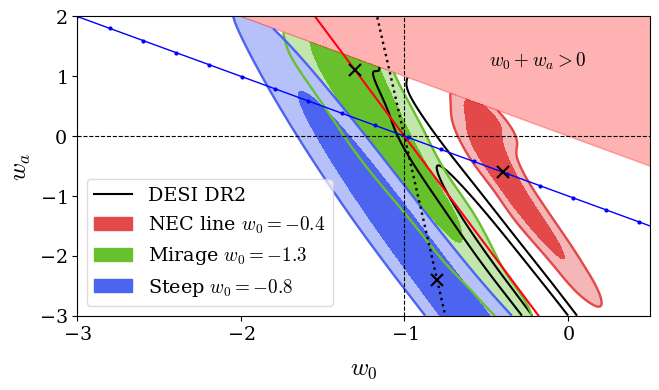

In [39]:
gd_samples, labels, contour_colors, filling, alphas, centers = load_chains(
    chains,
)

# fig, ax = plot_w0wa_contours(
#     gd_samples=gd_samples,
#     labels=labels,
#     contour_colors=contour_colors,
#     filling=filling,
#     alphas=alphas,
#     centers=centers,
#     xlim=(-3, 0.5),
#     # figsize=(8, 4),
#     # params=('omegam', 'hrdrag')
#     # savepath=path_to_fig + r'\shifted_w0wa\NEC_Mirage_steep.pdf',
# )

fig, ax = plot_w0wa_contours_rel_fs(
    gd_samples=gd_samples,
    labels=labels,
    contour_colors=contour_colors,
    filling=filling,
    alphas=alphas,
    centers=centers,
    xlim=(-3, 0.5),
    figsize=(7, 4),
    # params=('omegam', 'hrdrag')
    # savepath=path_to_fig + r'\shifted_w0wa\NEC_Mirage_steep_rel_fs.pdf',
)

fixed

In [21]:
chains = {
    # 'DESI DR2 LCDM': {
    #     'path':  r'C:\EPFL\MA4\code\old_stuff.bak\cobaya_runs\fake_data\Planck_flat_LCDM\exact\all_z\chain',
    #     'color': "#000000",
    #     'center': (-1.0, 0.0),
    # },
    'DESI DR2': {
        'path':  r'C:\EPFL\MA4\code\old_stuff.bak\DESI_DR2_chains\base_w_wa\desi-bao-all\chain',
        'color': "#000000",
        'fill':  False,
    },
    'NEC line $w_0=-0.4$': {
        'path':  r'C:\EPFL\MA4\code\PDM2026\wwa_pair_chains\fixed\NEC\chain',
        'color': "#E34949",
        'center': (-0.4, -0.6),
    },
    'Mirage $w_0=-1.3$': {
        'path':  r'C:\EPFL\MA4\code\PDM2026\wwa_pair_chains\fixed\Mirage\chain',
        'color': "#67C12C",
        'center': (-1.3, 1.1),
    },
    # 'LCDM': {
    #     'path':  r'C:\EPFL\MA4\code\PDM2026\wwa_pair_chains\LCDM\chain',
    #     'color': "#2580F6",
    #     'center': (-1.0, 0.0),
    #     'fill':  False,
    # },
    'Steep $w_0=-0.8$': {
        'path':  r'C:\EPFL\MA4\code\PDM2026\wwa_pair_chains\fixed\Steep\chain',
        'color': "#4C64EF",
        'center': (-0.8, -2.4),
    },
}

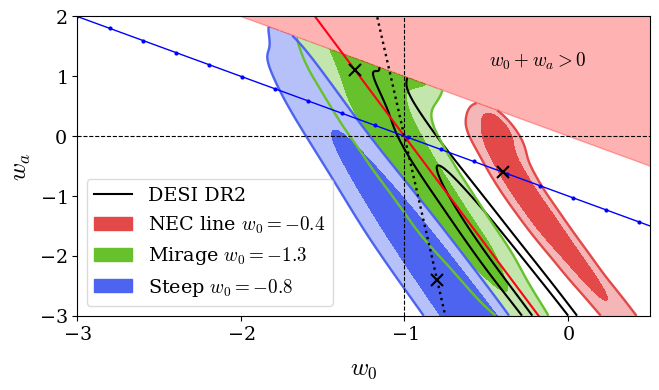

In [22]:
gd_samples, labels, contour_colors, filling, alphas, centers = load_chains(
    chains,
)


fig, ax = plot_w0wa_contours_rel_fs(
    gd_samples=gd_samples,
    labels=labels,
    contour_colors=contour_colors,
    filling=filling,
    alphas=alphas,
    centers=centers,
    xlim=(-3, 0.5),
    figsize=(7, 4),
    # params=('omegam', 'hrdrag')
    # savepath=path_to_fig + r'\shifted_w0wa\NEC_Mirage_steep_fixed.pdf',
)

In [23]:
print_FoM_slope_zp(gd_samples, labels)

DESI DR2: FoM = 13.7308, slope = -3.7734, zp = 0.3606
NEC line $w_0=-0.4$: FoM = 15.6102, slope = -4.1548, zp = 0.3170
Mirage $w_0=-1.3$: FoM = 6.3327, slope = -4.2278, zp = 0.3098
Steep $w_0=-0.8$: FoM = 7.7511, slope = -3.8146, zp = 0.3553


In [ ]:
# for i, samp in enumerate(gd_samples):
#     slope, slope_alt, zp, zp_alt = get_slope_pivot_z(samp)
#     print(f"{labels[i]} Slope: {slope:.3f}, Slope alt: {slope_alt:.3f}, Pivot z: {zp:.3f}, Pivot z alt: {zp_alt:.3f}")

DESI DR2 Slope: -3.752, Slope alt: -3.773, Pivot z: 0.363, Pivot z alt: 0.361
NEC line $w_0=-0.4$ Slope: -4.131, Slope alt: -4.155, Pivot z: 0.319, Pivot z alt: 0.317
Mirage $w_0=-1.3$ Slope: -4.172, Slope alt: -4.228, Pivot z: 0.315, Pivot z alt: 0.310
Steep $w_0=-0.8$ Slope: -3.782, Slope alt: -3.815, Pivot z: 0.359, Pivot z alt: 0.355


free

In [24]:
chains = {
    # 'DESI DR2 LCDM': {
    #     'path':  r'C:\EPFL\MA4\code\old_stuff.bak\cobaya_runs\fake_data\Planck_flat_LCDM\exact\all_z\chain',
    #     'color': "#000000",
    #     'center': (-1.0, 0.0),
    # },
    'DESI DR2': {
        'path':  r'C:\EPFL\MA4\code\old_stuff.bak\DESI_DR2_chains\base_w_wa\desi-bao-all\chain',
        'color': "#000000",
        'fill':  False,
    },
    'NEC line $w_0=-0.4$': {
        'path':  r'C:\EPFL\MA4\code\PDM2026\wwa_pair_chains\free\NEC\chain',
        'color': "#E34949",
        'center': (-0.4, -0.6),
    },
    'Mirage $w_0=-1.3$': {
        'path':  r'C:\EPFL\MA4\code\PDM2026\wwa_pair_chains\free\Mirage\chain',
        'color': "#67C12C",
        'center': (-1.3, 1.1),
    },
    # 'LCDM': {
    #     'path':  r'C:\EPFL\MA4\code\PDM2026\wwa_pair_chains\LCDM\chain',
    #     'color': "#2580F6",
    #     'center': (-1.0, 0.0),
    #     'fill':  False,
    # },
    'Steep $w_0=-0.8$': {
        'path':  r'C:\EPFL\MA4\code\PDM2026\wwa_pair_chains\free\Steep\chain',
        'color': "#4C64EF",
        'center': (-0.8, -2.4),
    },
}

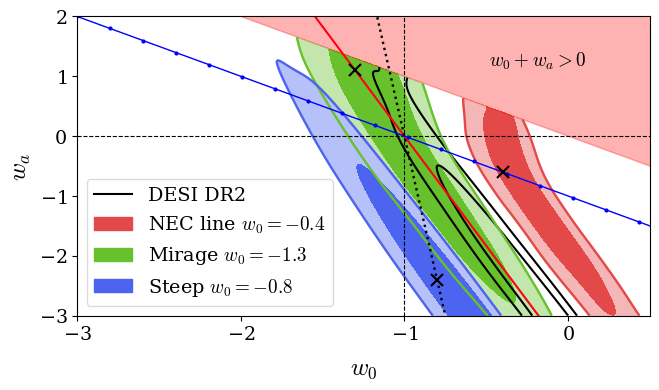

In [25]:
gd_samples, labels, contour_colors, filling, alphas, centers = load_chains(
    chains,
)

fig, ax = plot_w0wa_contours_rel_fs(
    gd_samples=gd_samples,
    labels=labels,
    contour_colors=contour_colors,
    filling=filling,
    alphas=alphas,
    centers=centers,
    xlim=(-3, 0.5),
    figsize=(7, 4),
    # params=('omegam', 'hrdrag')
    # savepath=path_to_fig + r'\shifted_w0wa\NEC_Mirage_steep_free.pdf',
)

In [26]:
print_FoM_slope_zp(gd_samples, labels)

DESI DR2: FoM = 13.7308, slope = -3.7734, zp = 0.3606
NEC line $w_0=-0.4$: FoM = 11.4269, slope = -4.3547, zp = 0.2981
Mirage $w_0=-1.3$: FoM = 6.4212, slope = -4.0848, zp = 0.3242
Steep $w_0=-0.8$: FoM = 11.3144, slope = -3.7215, zp = 0.3674


In [67]:
for i, samp in enumerate(gd_samples):
    slope, slope_alt, zp, zp_alt = get_slope_pivot_z(samp)
    print(f"{labels[i]} Slope: {slope:.3f}, Slope alt: {slope_alt:.3f}, Pivot z: {zp:.3f}, Pivot z alt: {zp_alt:.3f}")

DESI DR2 Slope: -3.752, Slope alt: -3.773, Pivot z: 0.363, Pivot z alt: 0.361
NEC line $w_0=-0.4$ Slope: -4.315, Slope alt: -4.355, Pivot z: 0.302, Pivot z alt: 0.298
Mirage $w_0=-1.3$ Slope: -4.037, Slope alt: -4.085, Pivot z: 0.329, Pivot z alt: 0.324
Steep $w_0=-0.8$ Slope: -3.697, Slope alt: -3.721, Pivot z: 0.371, Pivot z alt: 0.367


with CMB

In [104]:
chains = {
    # 'DESI DR2': {
    #     'path':  r'C:\EPFL\MA4\code\old_stuff.bak\cobaya_runs\DESI_data\base_w_wa\run1',
    #     'color': "#000000",
    #     'fill':  False,
    # },
    'DESI BAO+CMB': {
        'path':  r'C:\EPFL\MA4\code\old_stuff.bak\cobaya_runs\DESI_data\test_DESI_CMB_lik\DESI_CMB_all_run1',
        'color': "#000000",
        'fill':  False,
    },
    'CMB' : {
        'path':  r'C:\EPFL\MA4\code\old_stuff.bak\cobaya_runs\DESI_data\test_DESI_CMB_lik\onlyCMB\chain',
        'color': "#414141",
        'fill':  True,
        'alphas': 0.5
    },
    'Mirage CMB': {
        'path':  r'C:\EPFL\MA4\code\PDM2026\wwa_pair_chains\Mirage\BAO+CMB\w0_neg1.3_wa1.1\chain',
        'color': "#E047FF",
        'center': (-1.3, 1.1),
    },
    'NEC CMB': {
        'path':  r'C:\EPFL\MA4\code\PDM2026\wwa_pair_chains\NEC\BAO+CMB\w0_-0.4_wa_-0.6\chain',
        'color': "#B7D95F",
        'center': (-0.4, -0.6),
        'skip': 0.0
    },
    'Steep CMB': {
        'path':  r'C:\EPFL\MA4\code\PDM2026\wwa_pair_chains\Steep\BAO+CMB\w0_-0.8_wa_-2.4\chain',
        'color': "#8B134F",
        'center': (-0.8, -2.4),
    },
}

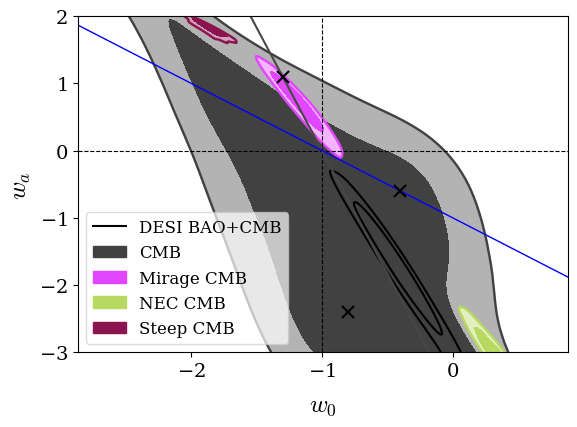

In [105]:
gd_samples, labels, contour_colors, filling, alphas, centers = load_chains(
    chains,
)

fig, ax = plot_w0wa_contours(
    gd_samples=gd_samples,
    labels=labels,
    contour_colors=contour_colors,
    filling=filling,
    alphas=alphas,
    centers=centers,
    # xlim=(-3, 0.5),
    # params=('omegam', 'hrdrag')
)

## $\chi^2$ check

### tests

In [173]:
chain1 = np.loadtxt(r'C:\EPFL\MA4\code\PDM2026\wwa_pair_chains\NEC_w0_0_wa_neg1\chain.2.txt')

In [87]:
columns = [
    'weight', 'minuslogpost', 'hrdrag', 'omch2', 'w', 'wa', 'As', 'rdrag', 'omegam', 'omegamh2', 'omega_de', 'YHe', 'Y_p', 'DHBBN', 'zrei', 'chi2__BAO', 'minuslogprior', 'minuslogprior__0', 'chi2', 'chi2__bao.desi_dr2'
]
columns.index('w')

4

In [151]:
# chi2_BAO = chain1[:, 15]  
chi2_chain = chain1[:, 18]
# chi2_baodesi_dr2 = chain1[:, 19] # these are all the same

In [152]:
hrdrag = chain1[:, 2]
omegam = chain1[:, 8]
omegamh2 = chain1[:, 9]
h = np.sqrt(omegamh2 / omegam)
w0 = chain1[:, 4]
wa = chain1[:, 5]
omegacdm = chain1[:, 3]/h**2
omegab = omegam - omegacdm
# print(f"omegab: {omegab.mean():.4f}, omegacdm: {omegacdm.mean():.4f}, h: {h.mean():.4f}, w0: {w0.mean():.4f}, wa: {wa.mean():.4f}")

In [174]:
def chi2(data, model, cov_inv):
    data = np.array(data)
    model = np.array(model)
    delta = data - model
    return delta.T @ cov_inv @ delta

In [175]:
def compute_deltachi2_from_chain(chain, z_DESI, model_w0, model_wa):
    # hrdrag = chain[:, 2]
    chi2_chain = chain[:, 18]
    omegam = chain[:, 8]
    omegamh2 = chain[:, 9]
    h = np.sqrt(omegamh2 / omegam)
    w0 = chain[:, 4]
    wa = chain[:, 5]
    omegacdm = chain[:, 3]/h**2
    omegab = omegam - omegacdm

    chisq_values = []

    cov_mat = np.loadtxt(r'C:\EPFL\MA4\code\COBAYA_packages\data\bao_data\desi_bao_dr2\desi_gaussian_bao_ALL_GCcomb_cov.txt')
    cov_inv = np.linalg.inv(cov_mat)

    DM_model, DH_model, DV_model = get_bao_observables(zbins=z_DESI, w0=model_w0, wa=model_wa, DESI_fiducial=True)
    model = [DV_model[0]]
    for i in range(1, len(z_DESI)):
        if i < len(z_DESI)-1:
            model.append(DM_model[i])
            model.append(DH_model[i])
        else:
            model.append(DH_model[i])
            model.append(DM_model[i])

    for k in range(len(chain)):  
        if k % 100 == 0:
            DM_data, DH_data, DV_data = get_bao_observables(zbins=z_DESI, w0=w0[k], wa=wa[k], Omega_cdm=omegacdm[k], Omega_b=omegab[k], h=h[k], DESI_fiducial=False)
            data = [DV_data[0]]
            for i in range(1, len(z_DESI)):
                if i < len(z_DESI)-1:
                    data.append(DM_data[i])
                    data.append(DH_data[i])
                else:
                    data.append(DH_data[i])
                    data.append(DM_data[i])

            chi2_value = chi2(data, model, cov_inv)
            # chisq_values.append((chi2_value-chi2_chain[k])/chi2_chain[k])  # Subtract the chi2 from the chain to get the difference
            chisq_values.append(chi2_value-chi2_chain[k])  # Subtract the chi2 from the chain to get the difference

    return np.array(chisq_values)


In [156]:
k = 0

DM_model, DH_model, DV_model = get_bao_observables(zbins=z_DESI, w0=0.0, wa=-1.0, DESI_fiducial=True)
model = [DV_model[0]]
for i in range(1, len(z_DESI)):
    if i < len(z_DESI)-1:
        model.append(DM_model[i])
        model.append(DH_model[i])
    else:
        model.append(DH_model[i])
        model.append(DM_model[i])

DM_data, DH_data, DV_data = get_bao_observables(zbins=z_DESI, w0=w0[k], wa=wa[k], Omega_cdm=omegacdm[k], Omega_b=omegab[k], h=h[k], DESI_fiducial=False)
data = [DV_data[0]]
for i in range(1, len(z_DESI)):
    if i < len(z_DESI)-1:
        data.append(DM_data[i])
        data.append(DH_data[i])
    else:
        data.append(DH_data[i])
        data.append(DM_data[i])

cov_mat = np.loadtxt(r'C:\EPFL\MA4\code\COBAYA_packages\data\bao_data\desi_bao_dr2\desi_gaussian_bao_ALL_GCcomb_cov.txt')

print(chi2(data, model, np.linalg.inv(cov_mat)))
print(chi2_chain[k])

4586.954345223225
8385.3188


### delta chi plot

In [251]:
fold = r'C:\EPFL\MA4\code\PDM2026\wwa_pair_chains'
filename = r'\Mirage\w0_neg1.3_wa1.1\chain'
# filename = r'\NEC_w0_0_wa_neg1\chain'
# filename = r'\LCDM\chain'
w0 = -1
wa = -3.66*(1+w0)
chain = [np.loadtxt(fold + filename + f'.{i}.txt') for i in range(1, 5)]

In [252]:
delta_chi2 = [compute_deltachi2_from_chain(ch, z_DESI, model_w0=w0, model_wa=wa) for ch in chain]

In [217]:
# delta_chi2 = compute_deltachi2_from_chain(chain1, z_DESI, model_w0=0.0, model_wa=-1.0)

Text(0, 0.5, '$\\Delta \\chi^2$')

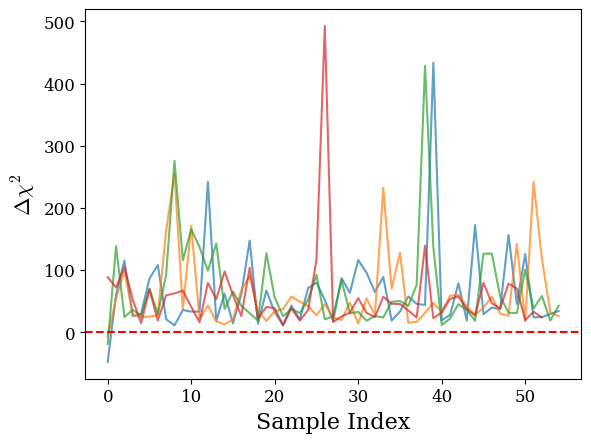

In [253]:
for i, dchi2 in enumerate(delta_chi2):
    plt.plot(dchi2, label=f'Chain {i+1}', alpha=0.7)
# plt.plot(delta_chi2, label='Delta Chi2', color='blue')
plt.axhline(0, color='red', linestyle='--', label='Zero Line')
plt.xlabel('Sample Index')
plt.ylabel(r'$\Delta \chi^2$')
# plt.ylabel('relative $\\Delta \\chi^2$')
# plt.yscale('log')
# plt.ylim(1e4, 1e5)